# KKBox — Population and Churn Definition

**Purpose:** (1) rebuild churn labels from the raw transactions with the rules of the official labeller and check them against the official `train.csv` and `train_v2.csv`; (2) explain where the rebuilt and the official populations differ; (3) build monthly cohorts across 2015–2017 to see how churn changes over time and what drives the swings.

**Evidence labels:** every result is a full-data result (every transaction row). *Rebuilt* means rebuilt with the demonstration rule of the official labeller (`src/churn_labels.py`; rules in [docs/churn_definition.md](../docs/churn_definition.md)). The official labels remain the reference for the February and March 2017 windows. Rebuilt and official rates describe different populations and must not be compared directly. Explanations marked *hypothesis* are not verified.

**Reading order:** setup → rebuilt against official labels → why the populations differ → monthly cohorts → findings.

**Run context:** open from the `notebooks/` directory. The monthly rebuild takes a few minutes the first time and is cached in `data/processed/` (git-ignored).

### 0. Setup

Registers the transaction and label files in DuckDB (nothing is loaded into memory) and a view `tx_all` that stacks the two transaction releases. The label rebuild needs both: the outcome of a February expiration is only visible in the March rows of `transactions_v2`.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src import audit_checks as ac
from src import churn_labels as cl
from src.audit_display import show

RAW_DIR = Path.cwd().parent / "data" / "raw"
CACHE_DIR = Path.cwd().parent / "data" / "processed"
try:
    from local_settings import TEMP_DIR   # machine-specific, git-ignored
except ImportError:
    TEMP_DIR = CACHE_DIR / "duckdb_tmp"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
Path(TEMP_DIR).mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
con.execute("SET memory_limit='8GB'")
con.execute(f"SET temp_directory='{TEMP_DIR}'")

for name, filename in {"tx_v1": "transactions.csv", "tx_v2": "transactions_v2.csv",
                       "train_v1": "train.csv", "train_v2": "train_v2.csv"}.items():
    ac.register_csv(con, name, RAW_DIR / filename)

TX_COLUMNS = ("msno, payment_method_id, payment_plan_days, plan_list_price, actual_amount_paid, "
              "is_auto_renew, transaction_date, membership_expire_date, is_cancel")
con.execute(f"CREATE OR REPLACE VIEW tx_all AS SELECT {TX_COLUMNS} FROM tx_v1 UNION ALL SELECT {TX_COLUMNS} FROM tx_v2")

## 1. Rebuilding the official labels

**Purpose:** check that the official labeller rules, applied to the raw transactions, reproduce the supplied labels, and so confirm which expiration month each label file covers (documented: `train.csv` February 2017, `train_v2.csv` March 2017).

**Logic:** for each target month the prediction cutoff is the last day of the previous month. A user's *last expiration* is taken from the history up to the cutoff in the labeller's order; users whose last expiration lies in the target month form the population. The renewal gap to the first later non-cancellation transaction (after cancellations that move the expiration earlier) decides the label: under 30 days is a renewal, 30 days or more, or no later transaction, is churn. The rebuilt users are then matched to the official file by `msno`.

**What to look for:** how much of the official file the rebuild covers, how often the labels agree among users in both, and in which direction the disagreements go.

In [2]:
OFFICIAL = {"2017-02": "train_v1", "2017-03": "train_v2"}
LABEL_NAMES = {0: "renewed", 1: "churn"}

rebuilt = {month: cl.rebuild_labels(con, "tx_all", **cl.month_window(month)) for month in OFFICIAL}

summary, matrices = [], {}
for month, table in OFFICIAL.items():
    con.register("rebuilt", rebuilt[month])
    n_official = con.sql(f"SELECT count(*) FROM {table}").fetchone()[0]
    joined = con.sql(f"""
        SELECT r.is_churn AS rebuilt_label, t.is_churn::INT AS official_label, count(*) AS users
        FROM rebuilt r JOIN {table} t USING (msno) GROUP BY ALL""").df()
    in_both = int(joined.users.sum())
    same = int(joined.loc[joined.rebuilt_label == joined.official_label, "users"].sum())
    summary.append({"target month": month, "rebuilt users": len(rebuilt[month]), "official users": n_official,
                    "in both": in_both, "official_covered_percentage": 100 * in_both / n_official,
                    "label_agreement_percentage": 100 * same / in_both})
    matrices[month] = (joined.pivot(index="rebuilt_label", columns="official_label", values="users")
                       .rename(index=lambda v: f"rebuilt: {LABEL_NAMES[v]}", columns=lambda v: f"official: {LABEL_NAMES[v]}"))

show("Rebuilt labels against the official label files", pd.DataFrame(summary).set_index("target month"),
     note="Agreement is measured among users present in both. Official users not rebuilt are examined in section 2.")
for month, matrix in matrices.items():
    show(f"Label comparison for {month} (users present in both)", matrix)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Rebuilt labels against the official label files**  
*Agreement is measured among users present in both. Official users not rebuilt are examined in section 2.*

,rebuilt users,official users,in both,official_covered_percentage,label_agreement_percentage
target month,,,,,
2017-02,"879,537","992,931","879,478",88.57%,98.36%
2017-03,"886,500","970,960","862,158",88.79%,95.73%


**Label comparison for 2017-02 (users present in both)**

official_label,official: renewed,official: churn
rebuilt_label,,
rebuilt: renewed,"830,514","14,193"
rebuilt: churn,199,"34,572"


**Label comparison for 2017-03 (users present in both)**

official_label,official: renewed,official: churn
rebuilt_label,,
rebuilt: renewed,"791,104","28,373"
rebuilt: churn,"8,438","34,243"


## 2. Why the rebuilt population differs from the official one

**Purpose:** the rebuild covers about 89% of each official file and finds a few users the official file lacks; this section shows who the missing users are.

**Logic:** at the cutoff, each official user is placed by the last expiration the labeller would use: no transaction up to the cutoff, last expiration before the window, after the window, or inside the window (rebuilt). Then a looser rule is tested: *any* transaction up to the cutoff, not only the last one, expiring in the target month.

**What to look for:** which groups hold the unrebuilt users and how their churn rates compare; and how much of each official file the looser rule covers. The looser rule is a working *hypothesis* for how the official sample was selected; it is not in the demonstration script.

In [3]:
position_tables, loose_rows = {}, []
for month, table in OFFICIAL.items():
    window = cl.month_window(month)
    con.register("last_exp", cl.last_expirations(con, "tx_all", window["cutoff"]))
    position_tables[month] = con.sql(f"""
        SELECT CASE WHEN l.msno IS NULL THEN '1 no transaction up to the cutoff'
                    WHEN l.last_expire < '{window["window_start"]}' THEN '2 last expiration before the window'
                    WHEN l.last_expire > '{window["window_end"]}' THEN '3 last expiration after the window'
                    ELSE '4 inside the window (rebuilt)' END AS position_at_cutoff,
               count(*) AS official_users,
               sum(t.is_churn::INT) AS churn_labels,
               round(100.0 * sum(t.is_churn::INT) / count(*), 2) AS churn_percentage
        FROM {table} t LEFT JOIN last_exp l USING (msno)
        GROUP BY 1 ORDER BY 1""").df().set_index("position_at_cutoff")

    con.register("loose", cl.users_expiring_in_window(con, "tx_all", **window))
    coverage = ac.coverage(con, table, "loose", "msno")["value"]
    loose_rows.append({"target month": month, "official users": coverage["left_keys"],
                       "covered by the looser rule": coverage["matched"],
                       "matched_percentage": coverage["matched_percentage"]})

for month, frame in position_tables.items():
    show(f"Where the official users of {month} sit at the cutoff", frame,
         note="Churn percentage is the share of official churn labels in each group.")
show("Official users covered by the looser rule (any expiration in the target month)",
     pd.DataFrame(loose_rows).set_index("target month"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Where the official users of 2017-02 sit at the cutoff**  
*Churn percentage is the share of official churn labels in each group.*

,official_users,churn_labels,churn_percentage
position_at_cutoff,,,
1 no transaction up to the cutoff,"2,095",661,31.55%
2 last expiration before the window,"18,490","7,668",41.47%
3 last expiration after the window,"92,868","6,377",6.87%
4 inside the window (rebuilt),"879,478","48,765",5.54%


**Where the official users of 2017-03 sit at the cutoff**  
*Churn percentage is the share of official churn labels in each group.*

,official_users,churn_labels,churn_percentage
position_at_cutoff,,,
1 no transaction up to the cutoff,"2,524","1,380",54.68%
2 last expiration before the window,"20,813","9,109",43.77%
3 last expiration after the window,"85,465","14,225",16.64%
4 inside the window (rebuilt),"862,158","62,616",7.26%


**Official users covered by the looser rule (any expiration in the target month)**

,official users,covered by the looser rule,matched_percentage
target month,,,
2017-02,"992,931","983,599",99.06%
2017-03,"970,960","958,189",98.68%


## 3. Monthly cohorts

**Purpose:** rebuild the population and label for every month the data allows, to see how churn moves over time.

**Logic:** the same rule is applied to each target month from 2015-02 to 2017-02, the last month whose 30-day outcome window ends inside the data (transactions end on 2017-03-31, so later months would count renewals we cannot see as churn). March 2017 is shown from the official file. The transaction history starts on 2015-01-01 and long plans stay invisible until renewed, so the months before 2015-07 are marked as a burn-in period; the start of the analysis period is a judgment, not a rule.

**What to look for:** the level and swings of the churn percentage, the growth of the cohorts, and how the official points compare. Rebuilt and official percentages are different populations and are not directly comparable.

In [4]:
FIRST_ANALYSIS_MONTH = "2015-07"
MONTHS = [f"{y}-{m:02d}" for y in (2015, 2016, 2017) for m in range(1, 13) if "2015-02" <= f"{y}-{m:02d}" <= "2017-02"]
CACHE = CACHE_DIR / "rebuilt_monthly_labels.parquet"   # git-ignored; delete the file to recompute

if CACHE.exists():
    cohorts = pd.read_parquet(CACHE)
else:
    cohorts = cl.rebuild_months(con, "tx_all", MONTHS)   # a few minutes
    cohorts.to_parquet(CACHE)

monthly = (cohorts.groupby("target_month").agg(users=("msno", "size"), churn_labels=("is_churn", "sum"))
           .assign(churn_percentage=lambda d: 100 * d.churn_labels / d.users))
monthly["period"] = ["burn-in" if m < FIRST_ANALYSIS_MONTH else "analysis" for m in monthly.index]

official = con.sql("""
    SELECT '2017-02' AS target_month, count(*) AS users, sum(is_churn::INT) AS churn_labels FROM train_v1
    UNION ALL SELECT '2017-03', count(*), sum(is_churn::INT) FROM train_v2""").df().set_index("target_month")
official["churn_percentage"] = 100 * official.churn_labels / official.users

show("Rebuilt monthly cohorts: users whose last expiration falls in the month", monthly, max_rows=40,
     note="Cohort = users expiring in the month under the rebuild rule; the label follows the 30-day renewal rule.")
show("Official label files for the two supplied windows (a different population)", official)

**Rebuilt monthly cohorts: users whose last expiration falls in the month**  
*Cohort = users expiring in the month under the rebuild rule; the label follows the 30-day renewal rule.*

,users,churn_labels,churn_percentage,period
target_month,,,,
2015-02,"393,443","14,461",3.68%,burn-in
2015-03,"409,311","17,976",4.39%,burn-in
2015-04,"487,544","93,773",19.23%,burn-in
2015-05,"427,260","25,648",6.00%,burn-in
2015-06,"433,220","35,619",8.22%,burn-in
2015-07,"497,579","27,599",5.55%,analysis
2015-08,"537,728","33,872",6.30%,analysis
2015-09,"572,078","60,280",10.54%,analysis
2015-10,"586,545","53,220",9.07%,analysis


**Official label files for the two supplied windows (a different population)**

,users,churn_labels,churn_percentage
target_month,,,
2017-02,"992,931","63,471",6.39%
2017-03,"970,960","87,330",8.99%


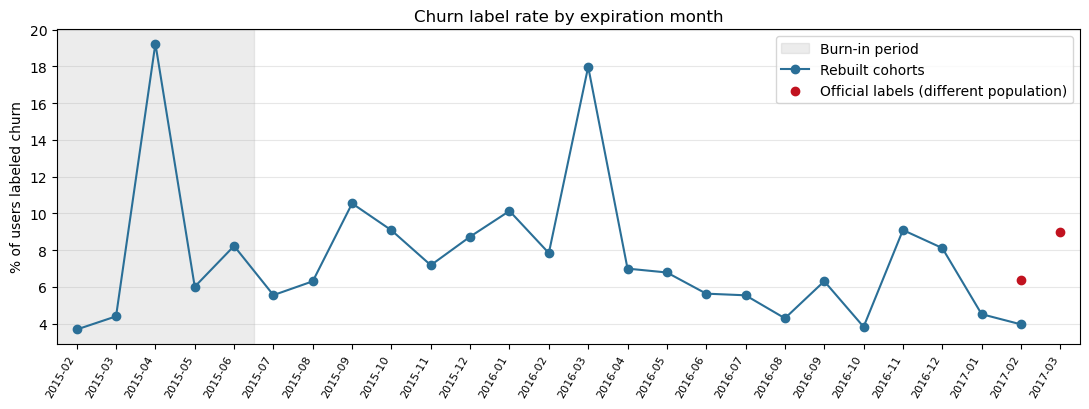

In [5]:
months_axis = list(monthly.index) + ["2017-03"]
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.axvspan(-0.5, (monthly.period == "burn-in").sum() - 0.5, color="#999999", alpha=0.18, label="Burn-in period")
ax.plot(monthly.index, monthly.churn_percentage, marker="o", color="#2a6f97", label="Rebuilt cohorts")
ax.scatter(official.index, official.churn_percentage, color="#c1121f", zorder=3,
           label="Official labels (different population)")
ax.set_xticks(range(len(months_axis)))
ax.set_xticklabels(months_axis, rotation=60, ha="right", fontsize=8)
ax.set_xlim(-0.5, len(months_axis) - 0.5)
ax.set_ylabel("% of users labeled churn")
ax.set_title("Churn label rate by expiration month")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 3.1 What drives the swings

**Purpose:** two months stand out (2015-04 and 2016-03). This section checks whether they come from a change in who expires or from a change in behavior.

**Logic:** for the months around each spike, the first table shows the plan behind each user's last expiration (share of 30-day plans, auto-renew, and zero list price) next to the churn percentage. The charts show the churn percentage by expiration day inside the two spike months.

**What to look for:** whether the spike months differ in plan mix, and whether the high churn sits on a few expiration days. A batch of users sharing one expiration day and a high churn rate would point to a campaign-style cohort (*hypothesis*; the cause is not in the data).

**Plan mix of the cohorts around the spike months**  
*Plan taken from the latest transaction whose expiration date equals the user's last expiration.*

,users,churn_percentage,thirty_day_plan_percentage,auto_renew_percentage,zero_list_price_percentage
target_month,,,,,
2015-03,"409,311",4.39%,69.40%,87.00%,0.00%
2015-04,"487,544",19.23%,59.00%,88.70%,15.30%
2015-05,"427,260",6.00%,53.90%,85.10%,21.90%
2016-02,"694,129",7.83%,98.10%,85.30%,0.30%
2016-03,"806,704",17.97%,95.50%,83.40%,2.50%
2016-04,"730,156",6.99%,97.50%,84.20%,0.10%


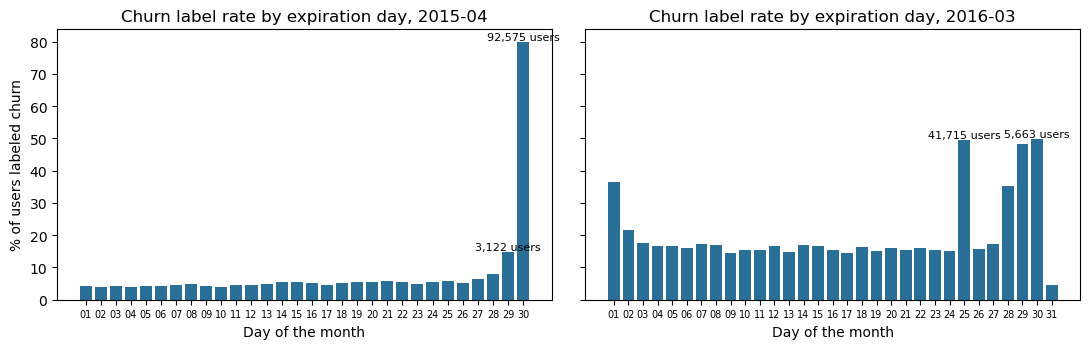

In [6]:
SPIKE_COMPARISON = ["2015-03", "2015-04", "2015-05", "2016-02", "2016-03", "2016-04"]
selected = cohorts[cohorts.target_month.isin(SPIKE_COMPARISON)][["target_month", "msno", "last_expire", "is_churn"]]
con.register("selected", selected)

mix = con.sql("""
    WITH j AS (
        SELECT s.target_month, s.msno, s.is_churn, t.payment_plan_days, t.is_auto_renew, t.plan_list_price,
               row_number() OVER (PARTITION BY s.target_month, s.msno ORDER BY t.transaction_date DESC) AS rn
        FROM selected s JOIN tx_all t ON t.msno = s.msno AND t.membership_expire_date = s.last_expire)
    SELECT target_month, count(*) AS users,
           round(100.0 * avg(is_churn), 2) AS churn_percentage,
           round(100.0 * avg(CASE WHEN payment_plan_days = '30' THEN 1 ELSE 0 END), 1) AS thirty_day_plan_percentage,
           round(100.0 * avg(CASE WHEN is_auto_renew = '1' THEN 1 ELSE 0 END), 1) AS auto_renew_percentage,
           round(100.0 * avg(CASE WHEN plan_list_price = '0' THEN 1 ELSE 0 END), 1) AS zero_list_price_percentage
    FROM j WHERE rn = 1 GROUP BY target_month ORDER BY target_month""").df().set_index("target_month")
show("Plan mix of the cohorts around the spike months", mix,
     note="Plan taken from the latest transaction whose expiration date equals the user's last expiration.")

by_day = con.sql("""
    SELECT target_month, substr(last_expire, 7, 2) AS expiry_day, count(*) AS users,
           round(100.0 * avg(is_churn), 1) AS churn_percentage
    FROM selected WHERE target_month IN ('2015-04', '2016-03') GROUP BY 1, 2 ORDER BY 1, 2""").df()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, month in zip(axes, ["2015-04", "2016-03"]):
    d = by_day[by_day.target_month == month]
    ax.bar(d.expiry_day, d.churn_percentage, color="#2a6f97")
    for _, row in d.nlargest(2, "churn_percentage").iterrows():
        ax.annotate(f"{int(row.users):,} users", (row.expiry_day, row.churn_percentage), ha="center",
                    va="bottom", fontsize=8)
    ax.set_title(f"Churn label rate by expiration day, {month}")
    ax.set_xlabel("Day of the month")
    ax.tick_params(axis="x", labelsize=7)
axes[0].set_ylabel("% of users labeled churn")
plt.tight_layout()
plt.show()

## 4. Findings, impact, and decisions

Full-data results (exploratory where marked); re-run the notebook to confirm them in your kernel.

| Area | Finding | Impact and decision |
|---|---|---|
| Label windows | With the cutoff at the end of the previous month, the rebuild covers 88.57% of `train.csv` (879,478 of 992,931 users) with 98.36% label agreement, and 88.79% of `train_v2.csv` (862,158 of 970,960) with 95.73% agreement | The files cover February and March 2017 expirations (strongly supported; the dates are documented and now checked against the transactions) |
| Right-censoring | Transactions end on 2017-03-31, so renewals after that date are invisible. In the March window the share of users rebuilt as churn but labeled renewed by the official file rises from 0.13% (expiring on days 1–7) to 2.22% (day 24 onward); it stays near 0.02% in February | Rebuilt labels are used only up to the 2017-02 cohort; March 2017 uses the official labels |
| Population | The rebuild misses 113,453 official users in February (92,868 with a last expiration after the window, 18,490 before it, 2,095 with no earlier transaction) and 108,802 in March. In February their churn percentages are 31.55%, 41.47%, and 6.87% for the three groups, against 5.54% for the rebuilt users; in March they are 54.68%, 43.77%, and 16.64% against 7.26%. The looser rule covers 99.06% and 98.68% of the official users | The official sample looks like users with any expiration in the target month (*hypothesis*). Rebuilt and official rates are different populations: 3.95% against 6.39% in February, 4.93% against 8.99% in March |
| Label treatment | Among shared users the official file marks more churn than the rebuild (14,193 users in February, 28,373 in March, against 199 and 8,438 the other way). About 70% of the February group are early renewers (renewal before the expiration) | How early renewers are labeled is an open question to settle before modeling (*hypothesis*: measured against a later expiration) |
| Monthly cohorts | Rebuilt cohorts grow from about 393 thousand users (2015-02) to about 880 thousand (2017-02); the churn label rate ranges from 3.7% to 19.2% | Analysis period 2015-07 to 2017-02 plus the official March 2017 file; earlier months are a shaded burn-in |
| Spike months | In 2015-04, 92,575 users expire on April 30 with 79.8% churn, and 15.3% of that month's cohort has a list price of zero (0.0% in 2015-03). In 2016-03 several expiration days show 35–50% churn | Consistent with campaign or trial-style cohorts (*hypothesis*; the cause is not in the data). Report plan mix and zero-price share next to churn over time |

**Open:** how early renewers are labeled; why the official sample includes users whose last expiration lies outside the month; the cause of the batch cohorts; the burn-in start (a judgment).